In [1]:
%pip install xlrd==2.0.1

   ---------------------------------------- 0.0/96.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/96.5 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/96.5 kB ? eta -:--:--
   ------------ --------------------------- 30.7/96.5 kB 262.6 kB/s eta 0:00:01
   --------------------- ------------------ 51.2/96.5 kB 375.8 kB/s eta 0:00:01
   ---------------------------------------- 96.5/96.5 kB 553.1 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [41]:
# %% ------------------------------------
# 📦 Configuración inicial
# %% ------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np
from pathlib import Path
import os
print(os.getcwd())
import statsmodels.api as sm  
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score 
from sklearn.metrics import RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score




sns.set(style="whitegrid")

c:\Users\User\OneDrive\Documentos\GitHub\Big-Data-UBA--Grupo-3\PRESENTACION FINAL\EPH 2016_3T


In [ ]:
# ======================================================
#  INTEGRACIÓN EPH 3T2016
# ======================================================

# ======================================================
# 1️⃣ DETECTAR RAÍZ DEL PROYECTO
# ======================================================
RUTA_REPO = Path.cwd()
while not (RUTA_REPO / ".git").exists() and RUTA_REPO != RUTA_REPO.parent:
    RUTA_REPO = RUTA_REPO.parent

RUTA_BASES = RUTA_REPO / "BASES"

print(f"📁 Raíz del repo: {RUTA_REPO}")
print(f"📂 Carpeta de bases: {RUTA_BASES}")

# ======================================================
# 2️⃣ CARGAR EPH INDIVIDUAL 3T2016
# ======================================================
archivo_eph = RUTA_BASES / "usu_individual_t316.xls"  # puede ser .xls o .xlsx

try:
    if archivo_eph.suffix == ".xls":
        # Para archivos .xls necesita xlrd
        eph_ind = pd.read_excel(archivo_eph, engine='xlrd')
    elif archivo_eph.suffix == ".xlsx":
        # Para archivos .xlsx necesita openpyxl
        eph_ind = pd.read_excel(archivo_eph, engine='openpyxl')
    else:
        raise ValueError("Formato de archivo no soportado. Debe ser .xls o .xlsx")

    print("✅ EPH individual 3T2016 cargada:", eph_ind.shape)
    print(eph_ind.head())

except ImportError as e:
    print("❌ Error de importación:", e)
    print("Para .xls instalar: pip install xlrd==2.0.1")
    print("Para .xlsx instalar: pip install openpyxl")
except FileNotFoundError:
    print("❌ Archivo no encontrado:", archivo_eph)
except Exception as e:
    print("❌ Otro error:", e)


📁 Raíz del repo: c:\Users\User\OneDrive\Documentos\GitHub\Big-Data-UBA--Grupo-3
📂 Carpeta de bases: c:\Users\User\OneDrive\Documentos\GitHub\Big-Data-UBA--Grupo-3\BASES
WARNING *** file size (99315329) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
✅ EPH individual 3T2016 cargada: (59550, 177)
                          CODUSU  ANO4  TRIMESTRE  NRO_HOGAR  COMPONENTE  H15  \
0  TQRMNOQWXHLMMLCDEFIAH00469008  2016          3          1           3    1   
1  TQRMNORPTHJMKTCDEFIAH00469111  2016          3          1           1    1   
2  TQRMNORPTHJMKTCDEFIAH00469111  2016          3          1           2    1   
3  TQRMNORPTHJMKTCDEFIAH00469111  2016          3          1           3    1   
4  TQRMNORPTHJMKTCDEFIAH00469111  2016          3          1           4    1   

   REGION MAS_500  AGLOMERADO  PONDERA  ...  PDECIFR  ADECIFR    IPCF  DECCFR  \
0      43       S           2      561  ...                07  8000.0  

In [3]:
# Mostrar todas las columnas de la EPH
print("Columnas de la EPH individual 3T2016:")
for i, col in enumerate(eph_ind.columns):
    print(f"{i+1:03d}: {col}")


Columnas de la EPH individual 3T2016:
001: CODUSU
002: ANO4
003: TRIMESTRE
004: NRO_HOGAR
005: COMPONENTE
006: H15
007: REGION
008: MAS_500
009: AGLOMERADO
010: PONDERA
011: CH03
012: CH04
013: CH05
014: CH06
015: CH07
016: CH08
017: CH09
018: CH10
019: CH11
020: CH12
021: CH13
022: CH14
023: CH15
024: CH15_COD
025: CH16
026: CH16_COD
027: NIVEL_ED
028: ESTADO
029: CAT_OCUP
030: CAT_INAC
031: IMPUTA
032: PP02C1
033: PP02C2
034: PP02C3
035: PP02C4
036: PP02C5
037: PP02C6
038: PP02C7
039: PP02C8
040: PP02E
041: PP02H
042: PP02I
043: PP03C
044: PP03D
045: PP3E_TOT
046: PP3F_TOT
047: PP03G
048: PP03H
049: PP03I
050: PP03J
051: INTENSI
052: PP04A
053: PP04B_COD
054: PP04B1
055: PP04B2
056: PP04B3_MES
057: PP04B3_ANO
058: PP04B3_DIA
059: PP04C
060: PP04C99
061: PP04D_COD
062: PP04G
063: PP05B2_MES
064: PP05B2_ANO
065: PP05B2_DIA
066: PP05C_1
067: PP05C_2
068: PP05C_3
069: PP05E
070: PP05F
071: PP05H
072: PP06A
073: PP06C
074: PP06D
075: PP06E
076: PP06H
077: PP07A
078: PP07C
079: PP07D
080: 

In [ ]:
### 

In [4]:
# ======================================================
# Resumen completo de la columna IPCF
# ======================================================

columna = 'IPCF'

# 1️⃣ Primeros registros
print("Primeros 10 registros:")
print(eph_ind[columna].head(10))

# 2️⃣ Tipos de datos y nulos
print("\nTipo de dato:", eph_ind[columna].dtype)
print("Cantidad de valores nulos:", eph_ind[columna].isna().sum())

# 3️⃣ Valores únicos
print("\nValores únicos:")
print(eph_ind[columna].unique())

# 4️⃣ Conteo de cada valor
print("\nConteo de cada valor:")
print(eph_ind[columna].value_counts(dropna=False))

# 5️⃣ Estadísticas descriptivas si es numérica
if pd.api.types.is_numeric_dtype(eph_ind[columna]):
    print("\nEstadísticas descriptivas:")
    print(eph_ind[columna].describe())
else:
    print("\nLa columna no es numérica, no se pueden calcular estadísticas numéricas.")


Primeros 10 registros:
0     8000.0
1        0.0
2        0.0
3        0.0
4        0.0
5    31000.0
6    31000.0
7        0.0
8        0.0
9        0.0
Name: IPCF, dtype: float64

Tipo de dato: float64
Cantidad de valores nulos: 0

Valores únicos:
[ 8000.       0.   31000.   ...  6326.67  8344.    6575.  ]

Conteo de cada valor:
IPCF
0.0        14889
5000.0       849
3000.0       827
4000.0       764
6000.0       679
           ...  
17154.0        1
6730.0         1
23800.0        1
10533.0        1
13107.0        1
Name: count, Length: 2540, dtype: int64

Estadísticas descriptivas:
count     59550.000000
mean       4655.383758
std        6313.078334
min           0.000000
25%           0.000000
50%        3087.500000
75%        6325.000000
max      267750.000000
Name: IPCF, dtype: float64


## Limpieza  de base

In [56]:
# ======================================================
# LIMPIEZA BASE EPH 3T2016 
# ======================================================

import pandas as pd

## Cambiar nombre de variables de interes

eph_ind_ren = eph_ind.rename(columns={   # Este es el nuevo df a usar
    'CH04': 'gen',
    'CH06': 'edad',
    'CH07': 'e_civil',
    'PP3E_TOT': 'ht_ocup_s',
    'NIVEL_ED': 'nivel_ed',
    'ESTADO': 'cond_act',
    'CH03': 'cond_parent',
    'CH09': 'alfabet',
    'CAT_OCUP': 'cat_ocup',
    'IPCF': 'percap_fam',
    'MAS_500': 'tama_aglomerado'
})

eph_ind_ren.head()
eph_ind_ren.columns

# ------------------------------------------------------
# 1️⃣ Variables que vamos a usar como predictores
## Se retiro CH10 por considerarla poco informativa
## Se agrego CAT_OCUP y MAS_500
# ------------------------------------------------------
VARS_PRED = [
    'gen','edad','e_civil','ht_ocup_s','nivel_ed','cond_act',
    'cond_parent','alfabet','cat_ocup','percap_fam' ,'tama_aglomerado'
]



In [57]:
## Valores unicos por variables seleccionadas

unique_summary = {
    var: {
        "n_unique": eph_ind_ren[var].nunique(),
        "unique_values": eph_ind_ren[var].unique()
    }
    for var in VARS_PRED
}

pd.DataFrame(unique_summary).T




,n_unique,unique_values
gen,2,"[1, 2]"
edad,99,"[17, 50, 48, 23, 15, 55, 34, 70, 61, 47, 45, 2..."
e_civil,6,"[5, 2, 3, 1, 4, 9]"
ht_ocup_s,106,"[nan, 70.0, 45.0, 63.0, 42.0, 78.0, 54.0, 84.0..."
nivel_ed,7,"[3, 6, 5, 4, 2, 1, 7]"
cond_act,5,"[3, 1, 4, 2, 0]"
cond_parent,10,"[3, 1, 2, 5, 8, 6, 9, 10, 4, 7]"
alfabet,4,"[1, 2, 3, 9]"
cat_ocup,6,"[0, 3, 2, 1, 4, 9]"
percap_fam,2539,"[8000.0, <NA>, 31000.0, 5000.0, 6500.0, 7666.6..."


In [58]:
# Limpieza de e_civil, el valor que debe pasar a missing es el 9

eph_ind_ren['e_civil'] = eph_ind_ren['e_civil'].replace(9, np.nan)




In [59]:
## Limpieza de horas trabajadas ocupacion principal

# ============================
# 2. Calcular percentil 99
# ============================
q99 = eph_ind_ren["ht_ocup_s"].quantile(0.99)
print(f"Percentil 99: {q99:.1f} horas")

# ============================
# 3. Reemplazar valores mayores al percentil 99 por NaN
# ============================
eph_ind_ren["ht_ocup"] = eph_ind_ren["ht_ocup_s"].where(eph_ind_ren["ht_ocup_s"] <= q99)

# ============================
# 4. Resumen de la variable limpia
# ============================
print(eph_ind_ren["ht_ocup"].describe())
#print("Valores únicos después de filtrar el percentil 99:", 
      #np.sort(["ht_ocup"].dropna().unique()))

## Nueva lista de predictores com ht_ocup

VARS_PRED1 = [
    'gen','edad','e_civil','ht_ocup','nivel_ed','cond_act',
    'cond_parent','alfabet','cat_ocup','percap_fam' ,'tama_aglomerado'
]



Percentil 99: 84.0 horas
count    24052.000000
mean        36.612382
std         16.613562
min          0.000000
25%         25.000000
50%         40.000000
75%         48.000000
max         84.000000
Name: ht_ocup, dtype: float64


Primeros 10 registros de PP3E_TOT:
0     NaN
1    70.0
2     NaN
3     NaN
4     NaN
5    45.0
6    63.0
7     NaN
8    42.0
9     NaN
Name: ht_ocup, dtype: float64

Tipo de dato: float64
Cantidad de valores nulos: 35498

Valores únicos:
[nan 70. 45. 63. 42. 78. 54. 84. 30. 50.  0. 40. 12. 72. 36. 48. 32. 20.
 24.  9. 56. 15. 10.  4. 66. 25. 55. 60. 16. 21.  8.  2. 44.  6. 35. 69.
 14. 65. 27. 18. 28. 22. 68.  3.  5. 26.  7. 34. 49. 46. 64. 11. 58. 57.
 23. 52. 80. 33. 75. 77. 37. 29. 67. 39. 51. 76. 53.  1. 47. 41. 43. 62.
 19. 13. 71. 38. 59. 79. 31. 17. 81. 82. 61. 73. 83. 74.]

Conteo de cada valor (top 20):
ht_ocup
40.0    3890
48.0    2761
30.0    2293
20.0    1389
45.0    1159
35.0     889
25.0     842
60.0     822
24.0     798
36.0     731
44.0     692
50.0     675
0.0      661
12.0     476
32.0     414
54.0     406
56.0     401
72.0     380
15.0     331
16.0     308
Name: count, dtype: int64

Estadísticas descriptivas:
count    24052.000000
mean        36.612382
std         16

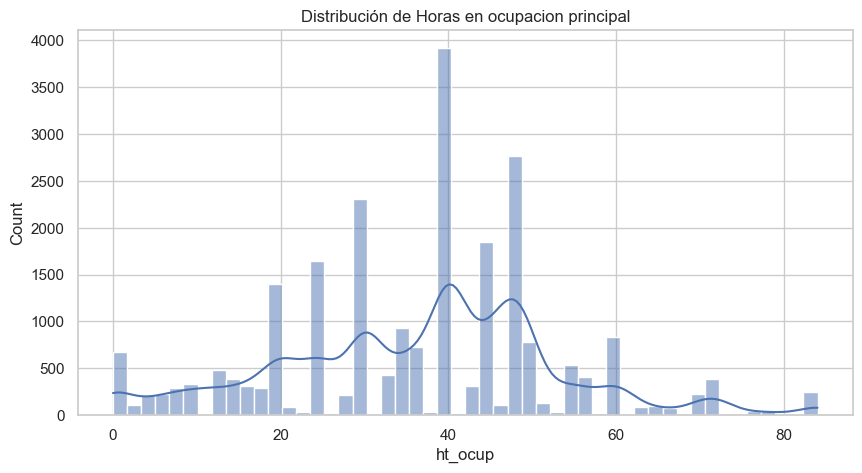

In [ ]:
# ======================================================
# Analisis th_ocupp
# ======================================================

# Primeros 10 registros
print("Primeros 10 registros de ht_ocup:")
print(eph_ind_ren['ht_ocup'].head(10))

# Tipo de dato
print("\nTipo de dato:", eph_ind_ren['ht_ocup'].dtype)

# Cantidad de valores nulos
print("Cantidad de valores nulos:", eph_ind_ren['ht_ocup'].isna().sum())

# Valores únicos
print("\nValores únicos:")
print(eph_ind_ren['ht_ocup'].unique())

# Conteo de cada valor
print("\nConteo de cada valor (top 20):")
print(eph_ind_ren['ht_ocup'].value_counts().head(20))

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(eph_ind_ren['ht_ocup'].describe())

## Grrafico  de horas trabajadas
plt.figure(figsize=(10,5))
sns.histplot(eph_ind_ren['ht_ocup'].dropna(), bins=50, kde=True)
plt.title("Distribución de Horas en ocupacion principal")
plt.show()


In [61]:
# Limpieza de alfabet, el valor que debe pasar a missing es el 9

eph_ind_ren['alfabet'] = eph_ind_ren['alfabet'].replace(9, np.nan)


In [63]:
# Limpieza de cat_ocup, los valoores que deben pasar a missing son el 0 y 9

eph_ind_ren['cat_ocup'] = eph_ind_ren['cat_ocup'].replace(0, np.nan)
eph_ind_ren['cat_ocup'] = eph_ind_ren['cat_ocup'].replace(9, np.nan)



In [64]:
# Limpieza de ingreso percapita familiar

# ------------------------------------------------------
#  Filtrar registros válidos: percap_fam y otras columnas clave
# ------------------------------------------------------
# Reemplazar ceros en percap_fam por NaN si representan "no respuesta"
eph_ind_ren['percap_fam'] = eph_ind_ren['percap_fam'].replace(0, pd.NA)

# Filtrar solo registros con IPCF válido
eph_limpia = eph_ind_ren[eph_ind_ren['percap_fam'].notna()].copy()

# ------------------------------------------------------
#  Seleccionar solo las variables de interés
# ------------------------------------------------------
eph_model = eph_limpia[VARS_PRED1].copy()


In [65]:
# Limpieza de tama_aglomerado
# See convierte en una dummy 0 = N y 1 = S
eph_ind_ren['tama_aglomerado'] = eph_ind_ren['tama_aglomerado'].map({'N': 0, 'S': 1})


In [66]:
# ------------------------------------------------------
# Revisar valores faltantes
# ------------------------------------------------------
faltantes = eph_model.isna().sum()
print("❗ Valores faltantes por variable:")
print(faltantes)

❗ Valores faltantes por variable:
gen                    0
edad                   0
e_civil                1
ht_ocup            27339
nivel_ed               0
cond_act               0
cond_parent            0
alfabet                0
cat_ocup           26288
percap_fam             0
tama_aglomerado        0
dtype: int64


In [68]:
# ======================================================
# LIMPIEZA E INTEGRACIÓN EPH 3T2016
# ======================================================

# ======================================================
# CALCULAR NIVEL DE POBREZA
# ======================================================
# Canasta básica total 3T2016 (promedio julio-septiembre)
CBT_3T2016 = (4033.76 + 4041.87 + 4089.82) / 3  # ≈4055.8

# Nivel de pobreza relativo
eph_model['nivel_pobreza'] = eph_model['percap_fam'] / CBT_3T2016

# Variable binaria: 1=pobre, 0=no pobre
eph_model['cond_pobre'] = (eph_limpia['percap_fam'] < CBT_3T2016).astype(int)

# ======================================================
# SELECCIONAR VARIABLES DE INTERÉS
# ======================================================
vars_interes = [
    'gen','edad','e_civil','ht_ocup','nivel_ed','cond_act',
    'cond_parent','alfabet','cat_ocup','percap_fam' ,'tama_aglomerado', 'nivel_pobreza'
, 'cond_pobre']

eph_model = eph_model[vars_interes].copy()
print("Base lista para análisis/modelado:", eph_model.shape)
print(eph_model.head())


Base lista para análisis/modelado: (44661, 13)
    gen  edad  e_civil  ht_ocup  nivel_ed  cond_act  cond_parent  alfabet  \
0     1    17      5.0      NaN         3         3            3      1.0   
5     2    55      3.0     45.0         4         1            1      1.0   
6     1    34      3.0     63.0         5         1            3      1.0   
10    1    47      1.0     78.0         3         1            1      1.0   
11    2    45      1.0      NaN         2         3            2      1.0   

    cat_ocup percap_fam tama_aglomerado nivel_pobreza  cond_pobre  
0        NaN     8000.0               S        1.9728           0  
5        3.0    31000.0               S        7.6446           0  
6        3.0    31000.0               S        7.6446           0  
10       3.0     5000.0               S         1.233           0  
11       NaN     5000.0               S         1.233           0  


In [40]:
# ======================================================
# GUARDAR BASE EPH LIMPIA PARA TRABAJO FUTURO
# ======================================================
CARPETA_SALIDA = RUTA_REPO / "BASES_TRABAJO"
CARPETA_SALIDA.mkdir(exist_ok=True)

eph_model.to_csv(CARPETA_SALIDA / "eph_3T2016_model_ready.csv", index=False)
print("✔ Base EPH 3T2016 guardada en BASES_TRABAJO lista para integración y análisis.")


✔ Base EPH 3T2016 guardada en BASES_TRABAJO lista para integración y análisis.
